# HAH913E Physical Activity Assignment

## GitHub Repository

https://github.com/SaidRodriguez22/Physical-activity-00.git

## Team Members
Zakia Hammaini

Rosy Boutouom-Messu

Daniel Reyes 

Said Rodriguez

## Objective

The goal is to compute ENMO (Euclidean Norm Minus One) from raw wrist accelerometer data and aggregate it using different epoch lengths (10 s, 30 s and 60 s).

Epoch aggregation reduces the data volume and allows comparison of physical activity intensity over time.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Loading the Data

The file contains:

- t: time in seconds
- x: acceleration along x-axis (g)
- y: acceleration along y-axis (g)
- z: acceleration along z-axis (g)

The data comes from a wrist-worn Axivity AX3 accelerometer.

In [4]:
df = pd.read_csv("C:\\Users\\Said Rodriguez\\Desktop\\M2\\Santé Physique\\0_z.csv")

df.head()

,t,x,y,z
0,0.00,-0.0938,-0.0156,0.9531
1,0.02,-0.0938,-0.0156,0.9531
2,0.04,-0.0938,-0.0156,0.9531
3,0.06,-0.0938,-0.0156,0.9531
4,0.08,-0.0938,-0.0156,0.9531


## Computing ENMO

First we calculate the Euclidean norm of the three acceleration components.


In [26]:
def compute_enmo(df):
    norm = np.sqrt(
        df["x"]**2 +
        df["y"]**2 +
        df["z"]**2
    )

    enmo = norm - 1

    return enmo

In [27]:
df["ENMO"] = compute_enmo(df)

## Aggregating ENMO by Epoch

An epoch is a fixed time window.

We calculate the mean ENMO value for epochs of:
- 10 seconds
- 30 seconds
- 60 seconds

In [28]:
def integrate_enmo(df, epoch_length):

    temp = df.copy()

    temp["epoch"] = (temp["t"] // epoch_length).astype(int)

    integrated = (
        temp.groupby("epoch")["ENMO"]
        .sum()
        .reset_index()
    )

    integrated["time"] = integrated["epoch"] * epoch_length

    return integrated

In [29]:
enmo_10 = integrate_enmo(df, 10)
enmo_30 = integrate_enmo(df, 30)
enmo_60 = integrate_enmo(df, 60)

In [30]:
dt = np.mean(np.diff(df["t"]))

## Plotting Results

We compare ENMO aggregated over three different epoch lengths.

Short epochs preserve more detail while longer epochs smooth fluctuations.

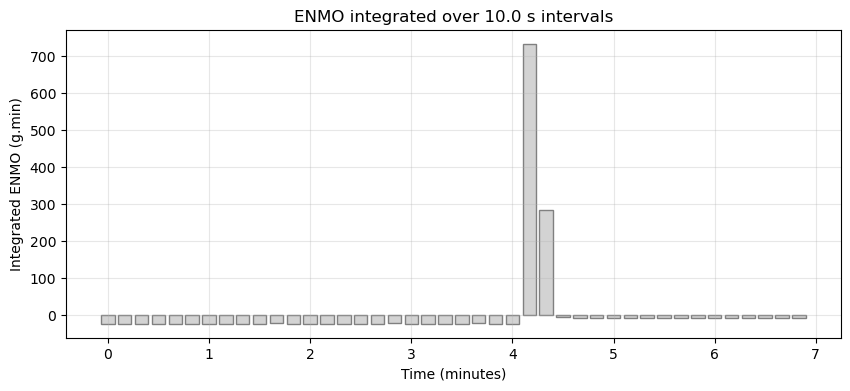

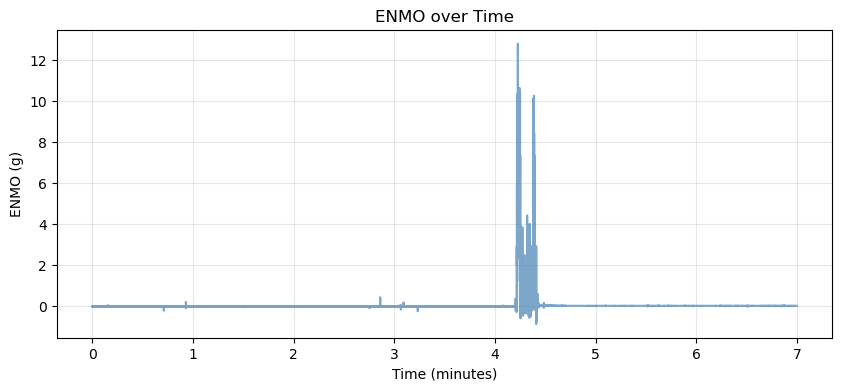

In [36]:
# 10 s epochs
enmo10 = integrate_enmo(df, 10)

# Plot like the assignment
plt.figure(figsize=(10,4))

plt.bar(
    enmo10["time"]/60,
    enmo10["ENMO"],
    width=8/60,
    color="lightgray",
    edgecolor="gray"
)

plt.title("ENMO integrated over 10.0 s intervals")
plt.xlabel("Time (minutes)")
plt.ylabel("Integrated ENMO (g.min)")
plt.grid(True, alpha=0.3)

plt.show()


# Raw ENMO graph underneath
plt.figure(figsize=(10,4))

plt.plot(
    df["t"]/60,
    df["ENMO"],
    color="steelblue",
    alpha=0.7
)

plt.title("ENMO over Time")
plt.xlabel("Time (minutes)")
plt.ylabel("ENMO (g)")
plt.grid(True, alpha=0.3)

plt.show()



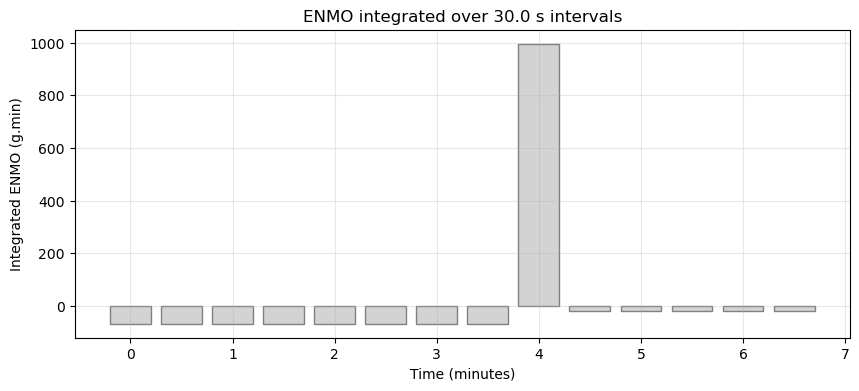

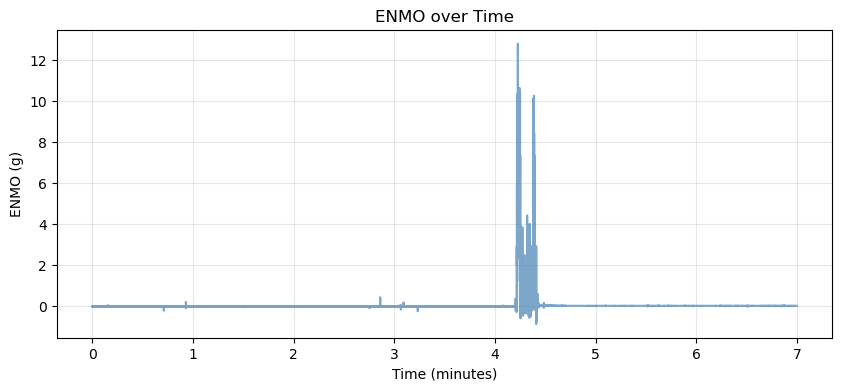

In [32]:
# 30 s epochs
enmo30 = integrate_enmo(df, 30)

# Plot like the assignment
plt.figure(figsize=(10,4))

plt.bar(
    enmo30["time"]/60,
    enmo30["ENMO"],
    width=24/60,
    color="lightgray",
    edgecolor="gray"
)

plt.title("ENMO integrated over 30.0 s intervals")
plt.xlabel("Time (minutes)")
plt.ylabel("Integrated ENMO (g.min)")
plt.grid(True, alpha=0.3)

plt.show()


# Raw ENMO graph underneath
plt.figure(figsize=(10,4))

plt.plot(
    df["t"]/60,
    df["ENMO"],
    color="steelblue",
    alpha=0.7
)

plt.title("ENMO over Time")
plt.xlabel("Time (minutes)")
plt.ylabel("ENMO (g)")
plt.grid(True, alpha=0.3)

plt.show()

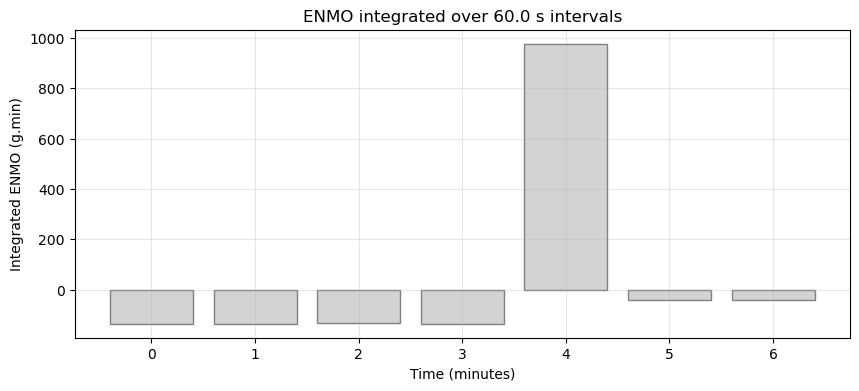

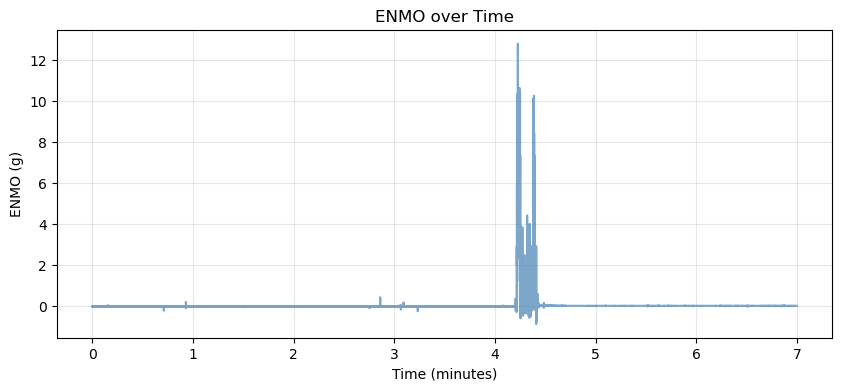

In [33]:
# 60 s epochs
enmo60 = integrate_enmo(df, 60)

# Plot like the assignment
plt.figure(figsize=(10,4))

plt.bar(
    enmo60["time"]/60,
    enmo60["ENMO"],
    width=48/60,
    color="lightgray",
    edgecolor="gray"
)

plt.title("ENMO integrated over 60.0 s intervals")
plt.xlabel("Time (minutes)")
plt.ylabel("Integrated ENMO (g.min)")
plt.grid(True, alpha=0.3)

plt.show()


# Raw ENMO graph underneath
plt.figure(figsize=(10,4))

plt.plot(
    df["t"]/60,
    df["ENMO"],
    color="steelblue",
    alpha=0.7
)

plt.title("ENMO over Time")
plt.xlabel("Time (minutes)")
plt.ylabel("ENMO (g)")
plt.grid(True, alpha=0.3)

plt.show()

## Discussion

The graphs show that there was very little movement during most of the recording. Most of the bars are close to zero. A short period of strong movement can be seen around 4 minutes.

With the 10-second epochs, the movement is divided into smaller pieces. This allows us to see more details and identify exactly when the movement happened.

With the 30-second epochs, the data are grouped into larger time periods. The graph becomes smoother and the small details start to disappear.

With the 60-second epochs, the data are grouped even more. The graph shows only one large peak, making it easy to see the general activity level, but it is harder to know exactly when the movement occurred.

In all three graphs, the same activity period is detected. The main difference is that larger epochs give a simpler and smoother view of the data, while smaller epochs show more detail.

## Conclusion

The 10-second epoch is best for seeing detailed changes in movement. The 30-second and 60-second epochs simplify the data and make overall activity easier to observe. Choosing the epoch length is a balance between keeping details and making the data easier to understand.